In [69]:
import numpy as np
import infomeasure as im 
import matplotlib.pyplot as plt 


from matplotlib import rc
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica Neue']})


In [70]:
NOISE_LEVEL = 0.1

In [71]:
x = np.linspace(-1, 1, 100)

normal_z = np.random.normal(size=len(x))

y = lambda x, a: x + a*(np.sin(2*np.pi*x**3)) + NOISE_LEVEL*normal_z

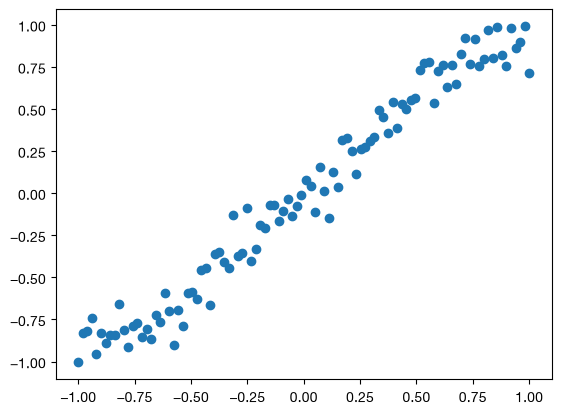

In [72]:
plt.scatter(x, y(x,0.1))

In [73]:
def pearson_corr(x, y): 
    num = np.mean((x-np.mean(x)) * (y-np.mean(y)))
    den = np.std(x) * np.std(y)
    return num / den

In [74]:
a_arr = np.linspace(0, 10, 10)
rho_arr = []
lam_arr = []
for i,a in enumerate(a_arr):
    tmp = y(x, a)
    rho = pearson_corr(x, tmp)
    I = im.mutual_information(x, tmp, approach='metric', k=4)
    lam = np.sqrt(1 - np.exp(-2*I))
    rho_arr.append(rho)
    lam_arr.append(lam) 

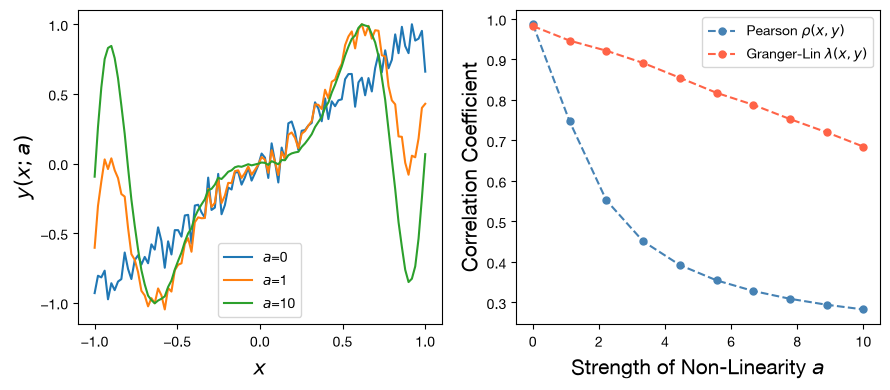

In [79]:
FONT_SIZE = 15
fig, axs = plt.subplots(1, 2, figsize=(9, 4))

axs[0].plot(x, y(x, 0)/np.max(y(x,0)), label='$a$=0')
axs[0].plot(x, y(x, 1.0)/np.max(y(x,1.0)), label='$a$=1')
axs[0].plot(x, y(x, 10.0)/np.max(y(x,10.0)), label='$a$=10')
axs[0].legend()
axs[0].set_xlabel('$x$', fontsize=FONT_SIZE)
axs[0].set_ylabel('$y(x; a)$', fontsize=FONT_SIZE)

axs[1].plot(a_arr, rho_arr, '.--', color='steelblue', markersize=10,label='Pearson $\\rho(x,y)$')
axs[1].plot(a_arr, lam_arr, '.--', color='tomato', markersize=10, label='Granger-Lin $\\lambda(x,y)$')
axs[1].set_xlabel('Strength of Non-Linearity $a$', fontsize=FONT_SIZE)
axs[1].set_ylabel('Correlation Coefficient', fontsize=FONT_SIZE)
axs[1].legend()

plt.tight_layout()